In [226]:
# Устанавливаем датасет

import kagglehub

kagglehub.login()

# Download latest version
# C:\Users\Артем\.cache\kagglehub\competitions\titanic
path = kagglehub.competition_download('titanic')

print("Path to competition files:", path)

Path to competition files: C:\Users\Артем\.cache\kagglehub\competitions\titanic


Intuition:<br>
Бустинг часто превосходит другие методы на табличных данных потому что хорошо работает с нелинейными зависимостями и признаками разных типов без сложной предобработки. CatBoost выбран потому что нативно обрабатывает категориальные признаки без ручного кодирования (фичи: Pclass, Sex, Embarked).<br>
У нас задача на бинарную классификацию, поскольку необходимо предсказать вероятность выживания при пороге 0.5 и перевести ее в метку 0 или 1. Можно пойти следующим путем. Построить логрег как baseline, а основной pipeline написать, используя CatBoost.

Семантический анализ данных:<br>
survival    -   target<br>
pclass      -   Номер класса (может выступать делителем по соц.статусу)<br>
sex 	    -   Пол<br>
Age         -   Возраст<br>
sibsp       -   Родственники/супруги<br>
parch       -   Родители-дети (можно сложить с sibsp в новый признак famsize)<br>
ticket      -   Номер билета (возможно, является шумом)<br>
fare        -   Стоимость (аналогично pclass по соц.статусу)<br>
cabin       -   Номер каюты (либо отсутствует)<br>
embarked    -   Порт посадки (предполагаю, что не окажет особого влияния на рез-т)<br>

Полезность фичей необходимо проверить разведочным анализом

In [227]:
# Установка зависимостей
import sklearn
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import StratifiedKFold

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [228]:
# В будущем нужно будет reset_index для submission на kaggle
train_df = pd.read_csv(f"{path}/train.csv").set_index('PassengerId')
test_df = pd.read_csv(f"{path}/test.csv").set_index('PassengerId')

print(train_df['Name'].head(3))
# test_df.head(3)

# train_df.info()
train_df.describe()

PassengerId
1                              Braund, Mr. Owen Harris
2    Cumings, Mrs. John Bradley (Florence Briggs Th...
3                               Heikkinen, Miss. Laina
Name: Name, dtype: str


,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Анализируя describe по числовым фичам, можно сказать следующее:
1. Survived показывает, что выжило 38%, что говорит о дисбалансе классов, но он не критичен.
2. Pclass. Нужно выделить примечание по датасету, что номера 1, 2 и 3 соответствовали классу, где 1 - наилучший, 3 - наихудший из возможных. Среднее 2.3 косвенно говорит о том, что подавляющее большинство относилось к классу 3, прямо об этом говорят квартили 2 и 3 (более 50% в 3 классе).
3. Age имеет пропущенные значения, средний возраст 29 лет, а стандартное отклонение 14 лет, но наиболее интересными являются строки min и max показывающие, что на борту находился младенец и пожилой человек в возрасте 0.42 и 80 соответственно.
4. SibSp и Parch предлагаю объединить в фичу FamSize = SibSp + Parch + 1. Исходно у нас два признака, указывающих на близость людей, которые несут одну и ту же логику, что эти люди, вероятно, будут помогать друг другу, что конечно же вовсе не факт. Однако, раз оба признака по смыслу несут одно и то же, то их можно просто слить воедино, показав размер группы, которая будет пытаться выжить.
5. Fare не имеет пропущенных значений, но в минимуме имеет ноль, похоже некоторые билеты достались людям бесплатно (экипаж, младенцы). Есть гипотеза, что были влиятельные люди или сделавшие свой вклад в запуск Титаника, но она требует проверки.

In [229]:
for i in train_df:
    print(i, train_df[i].isna().sum())

Survived 0
Pclass 0
Name 0
Sex 0
Age 177
SibSp 0
Parch 0
Ticket 0
Fare 0
Cabin 687
Embarked 2


В некоторых колонках имеются пропущенные значения. Можно сразу наметить дальнейшую стратегию:<br>
1. Cabin = 687 NaN значений. Сам по себе признак бесполезен, но можно перевернуть его в факт наличия значения, тогда признак окажется более полезным (MissingIndicator)
2. Age = 177, что составляет почти 20% всех значений. Нужно заполнить средним или медианой NaN значения. Выбор будет сделан после рассмотрения распределения данных. При симметричном распределении разницы нет, а при выбросах или скосах стоит взять более устойчивую медиану.
3. Embarked = 2. Сущая мелочь, можно использовать стратегию SimpleImputer'а 'most_frequent'

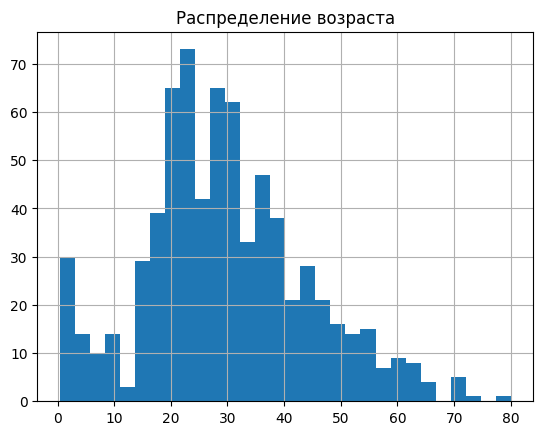

mean: 29.69911764705882
median: 28.0


In [230]:
train_df['Age'].hist(bins=30)
plt.title('Распределение возраста')
plt.show()

print("mean:", train_df['Age'].mean())
print("median:", train_df['Age'].median())

Гистограмма показывает хвост справа + не является симметричной, из-за чего среднее "утягивается" вверх. Берем медиану, которая оказалась более устойчивой. Применим групповую импутацию, поскольку пропущенных значений слишком много (~20%). Проверим разницу по классам и полу, имеет ли она смысл?

In [231]:
train_df.groupby(['Pclass', 'Sex'])['Age'].median()

Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64

Проверка медианы по группам показала разброс от 21.5 до 40.0, что является очень большим разбросом, чтобы просто применять медиану => используем групповую импутацию.

In [232]:
train_df['group_median'] = train_df.groupby(['Pclass', 'Sex'])['Age'].transform('median')
train_df['Age'] = train_df['Age'].fillna(train_df['group_median'])
train_df.drop(columns=['group_median'], inplace=True)

print(train_df['Age'].count())

891


In [233]:
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

print(train_df['Embarked'].isna().sum())

0


In [234]:
train_df['FamSize'] = train_df['SibSp'] + train_df['Parch'] + 1
print(train_df[['SibSp', 'Parch', 'FamSize']].head(10))
train_df.drop(columns=['SibSp', 'Parch'], inplace=True)

             SibSp  Parch  FamSize
PassengerId                       
1                1      0        2
2                1      0        2
3                0      0        1
4                1      0        2
5                0      0        1
6                0      0        1
7                0      0        1
8                3      1        5
9                0      2        3
10               1      0        2


In [235]:
train_df['HasCabin'] = ~train_df['Cabin'].isna()
print(train_df[['Cabin', 'HasCabin']].head(10))
train_df.drop(columns=['Cabin'], inplace=True)

            Cabin  HasCabin
PassengerId                
1             NaN     False
2             C85      True
3             NaN     False
4            C123      True
5             NaN     False
6             NaN     False
7             E46      True
8             NaN     False
9             NaN     False
10            NaN     False


In [236]:
title_mapping = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
}

train_df['Title'] = train_df['Name'].str.split(',').str[1].str.split('.').str[0].str.strip()
train_df['Title'] = train_df['Title'].map(title_mapping).fillna('Rare')

train_df.drop(columns=['Name', 'Ticket'], inplace=True)
train_df.info()
print(train_df['Title'].value_counts())
print(train_df.groupby('Title')['Survived'].mean())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       891 non-null    float64
 4   Fare      891 non-null    float64
 5   Embarked  891 non-null    str    
 6   FamSize   891 non-null    int64  
 7   HasCabin  891 non-null    bool   
 8   Title     891 non-null    str    
dtypes: bool(1), float64(2), int64(3), str(3)
memory usage: 56.7 KB
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64
Title
Master    0.575000
Miss      0.702703
Mr        0.156673
Mrs       0.793651
Rare      0.347826
Name: Survived, dtype: float64


Результаты разведочного анализа были применены к датасету. Переходим к предварительной обработке данных (EDA)

In [237]:
print(train_df.groupby('Sex')['Survived'].mean())
print(train_df.groupby('Pclass')['Survived'].mean())
print(train_df.groupby('Embarked')['Survived'].mean())

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64
Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64


Анализ вклада категориальных признаков в выживаемость показал, что:
1. Женщины выживали на порядок чаще мужчин. Предположительно, по той причине, что мужчин рассаживали по шлюпкам в последнюю очередь
2. Зависимость выживаемости от класса очевидна по среднему для каждого класса
3. По какой-то причине, больше половины людей, севших на Титаник в Шербуре, выжило, когда у остальных выживаемость колеблется около трети. Можно предположить, что в Шербуре село много персон 1 и 2 класса, но гипотеза требует проверки.

In [238]:
train_df.groupby(['Embarked', 'Pclass']).size().unstack()

Pclass,1,2,3
Embarked,,,
C,85,17,66
Q,2,3,72
S,129,164,353


Гипотеза подтвердилась, больше половины людей из Шербура первого и второго класса

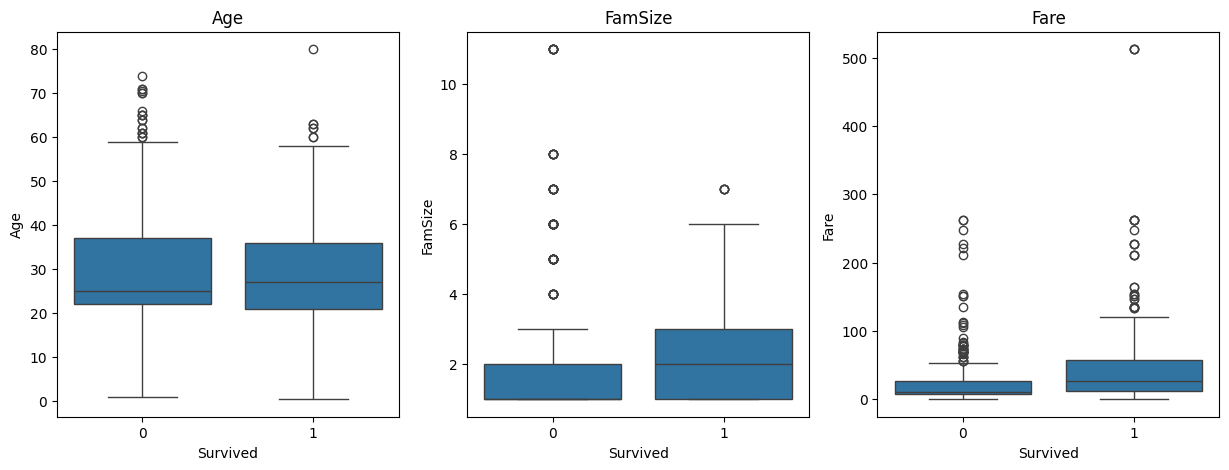

In [239]:
fig, axes = plt.subplots(1,3,figsize=(15,5))

for ax, col in zip(axes, ['Age', 'FamSize', 'Fare']):
    sns.boxplot(data=train_df, x = 'Survived', y=col, ax=ax)
    ax.set_title(col)

plt.tight_layout
plt.show()

1. Age - боксы для 0 и 1 почти одинаковые, следовательно возраст сам по себе слабо предсказывает выживание
2. FamSize - у выживших медиана чуть выше, значит одиночки выживали хуже
3. Fare - у выживших медиана и box заметно выше => чем выше цена, тем выше шанс

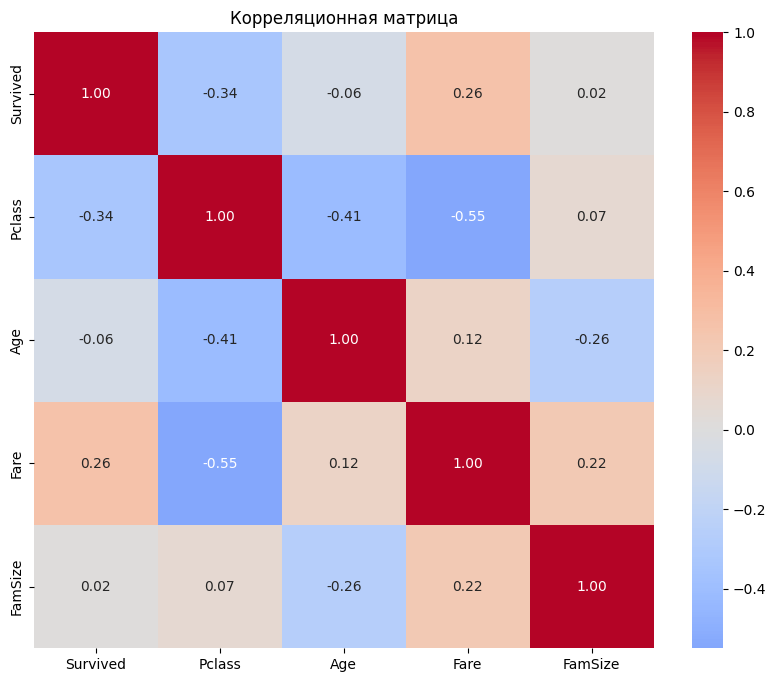

In [240]:
corr = train_df.select_dtypes(include='number').corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляционная матрица')
plt.show()

Анализ матрицы:<br>
Survived:
1. Pclass: -0.34 - сильнейший числовой предиктор
2. Fare: +0.26 - по смыслу дублирует Pclass
3. Age: -0.06 - почти ноль, линейной связи нет
4. FamSize: +0.02 - ноль

Pclass & Age: -0.41 - пассажиры первого класса были заметно старше<br>
Age & FamSize: -0.26 - молодые люди ехали бОльшими семьями<br>
Fare & FamSize: +0.22 - семьи суммарно платили больше, либо семьи были богатыми

Pclass & Fare: -0.55 - мультиколлинеарность. Для логрега это потенциальная проблема, однако для CatBoost не критично в силу его архитектуры, построенной на деревьях.

Также нужно помнить, что лучшим предикатором является категориальный признак Sex, просто в корр матрицу он не попал из-за типа данных.

In [241]:
# Сохраняем медианы из train — применяем к test, чтобы избежать data leakage
age_medians = train_df.groupby(['Pclass', 'Sex'])['Age'].median()

title_mapping = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
    'Rare': ['Dr', 'Rev', 'Major', 'Mlle', 'Col', 'Don', 'Mme', 'Ms', 'Lady', 'Sir', 'Capt', 'the Countess', 'Jonkheer']
}

# Применяем все преобразования к test_df
test_df['Title'] = test_df['Name'].str.split(',').str[1].str.split('.').str[0].str.strip()
test_df['Title'] = test_df['Title'].map(title_mapping).fillna('Rare')

test_df['Age'] = test_df.apply(
    lambda row: age_medians[row['Pclass'], row['Sex']] if pd.isna(row['Age']) else row['Age'],
    axis=1
)
test_df['Embarked'] = test_df['Embarked'].fillna(train_df['Embarked'].mode()[0])
test_df['Fare'] = test_df['Fare'].fillna(train_df['Fare'].median())
test_df['FamSize'] = test_df['SibSp'] + test_df['Parch'] + 1
test_df.drop(columns=['SibSp', 'Parch'], inplace=True)
test_df['HasCabin'] = ~test_df['Cabin'].isna()
test_df.drop(columns=['Cabin'], inplace=True)
test_df.drop(columns=['Name', 'Ticket'], inplace=True)

test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 892 to 1309
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Sex       418 non-null    str    
 2   Age       418 non-null    float64
 3   Fare      418 non-null    float64
 4   Embarked  418 non-null    str    
 5   Title     418 non-null    str    
 6   FamSize   418 non-null    int64  
 7   HasCabin  418 non-null    bool   
dtypes: bool(1), float64(2), int64(2), str(3)
memory usage: 23.4 KB


Создаём датасеты для логрега (без Fare) и применяем OHE к Sex и Embarked.
`drop_first=True` убирает одну колонку из каждой группы — защита от dummy variable trap.
OHE применяется к объединённому датасету, чтобы гарантировать одинаковый набор колонок в train и test.

In [242]:
train_lr = train_df.drop(columns=['Fare'])
test_lr = test_df.copy()

combined = pd.concat([train_lr, test_lr])
combined = pd.get_dummies(combined, columns=['Sex', 'Embarked', 'Title'], drop_first=True)

train_lr = combined.iloc[:len(train_df)]
test_lr = combined.iloc[len(train_df):].drop(columns=['Survived'], errors='ignore')

print("train_lr:", train_lr.shape, train_lr.columns.tolist())
print("test_lr: ", test_lr.shape, test_lr.columns.tolist())

train_lr: (891, 13) ['Survived', 'Pclass', 'Age', 'FamSize', 'HasCabin', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']
test_lr:  (418, 12) ['Pclass', 'Age', 'FamSize', 'HasCabin', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']


Проверка итоговых датафреймов перед обучением моделей.

In [243]:
print("=== train_df (CatBoost) ===")
train_df.info()
print("\n=== test_df (CatBoost) ===")
test_df.info()
print("\n=== train_lr (LogReg) ===")
print(train_lr.shape, train_lr.columns.tolist())
print("\n=== test_lr (LogReg) ===")
print(test_lr.shape, test_lr.columns.tolist())

=== train_df (CatBoost) ===
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       891 non-null    float64
 4   Fare      891 non-null    float64
 5   Embarked  891 non-null    str    
 6   FamSize   891 non-null    int64  
 7   HasCabin  891 non-null    bool   
 8   Title     891 non-null    str    
dtypes: bool(1), float64(2), int64(3), str(3)
memory usage: 56.7 KB

=== test_df (CatBoost) ===
<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 892 to 1309
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Sex       418 non-null    str    
 2   Age       418 non-null    float64
 3   Fare      418 non-null    float64
 4   Embarked  418 non-n

Построим сначала baseline LogReg

In [244]:
X = train_lr.drop(columns=['Survived', 'Fare'])
y = train_lr['Survived']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

X_test = test_lr.drop(columns=['Fare'])

model = LogisticRegression(penalty='l2',
                           C = 0.15,
                           solver='lbfgs',
                           max_iter=200,
                           random_state=42)

model.fit(X_train, y_train)
val_preds = model.predict(X_val)

print(f"Accuracy: {accuracy_score(y_val, val_preds):.4f}")
print(classification_report(y_val, val_preds, target_names=['Not Survived', 'Survived']))

val_probs = model.predict_proba(X_val)[:, 1]
print(f"ROC-AUC: {roc_auc_score(y_val, val_probs):4f}")

Accuracy: 0.8101
              precision    recall  f1-score   support

Not Survived       0.83      0.85      0.84       105
    Survived       0.78      0.76      0.77        74

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

ROC-AUC: 0.887838


c:\Users\Артем\Desktop\VUZ\Kaggle\Titanic\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Хороший результат для baseline = 83.8%<br>
Нужно оценить классификационные метрики:
1. Recall=0.76 (s): говорит, что каждого четвертого выжившего модель пропускает (FN). Все дело в смещении модели в сторону предсказания смерти (данных о погибших больше). Recall=0.90 (ns): говорит о том, что модель пропускает каждого 10 погибшего, считая его выжившим (FP).
2. Precision=0.84 (s & ns): говорит о том, что из всех предсказаний модели 84% были точными как для survived, так и для not survived.

Эту планку CatBoost должен превзойти

UPD: По ошибке добавил обработку 'Title' в baseline из-за чего значения метрик обновились. Ориентироваться буду на старые метрики, записанные в этом markdown'е.

In [245]:
X_cb = train_df.drop(columns=['Survived'])
y_cb = train_df['Survived']

X_cb_train, X_cb_val, y_cb_train, y_cb_val = train_test_split(X_cb, y_cb, 
                                                               test_size=0.2,
                                                               random_state=42)
X_cb_test = test_df
cat_features = ['Sex', 'Embarked', 'Title']

model_cb = CatBoostClassifier(
    iterations=1400,
    learning_rate=0.025,
    depth=5,
    random_seed=42,
    verbose=200
)

model_cb.fit(X_cb_train, y_cb_train, cat_features=cat_features, eval_set=(X_cb_val, y_cb_val))

val_cb_preds = model_cb.predict(X_cb_val)
print(f"Accuracy: {accuracy_score(y_cb_val, val_cb_preds):.4f}")
print(classification_report(y_cb_val, val_cb_preds, target_names=['Not Survived', 'Survived']))

val_cb_probs = model_cb.predict_proba(X_cb_val)[:, 1]
print(f"ROC-AUC: {roc_auc_score(y_cb_val, val_cb_probs):.4f}")

0:	learn: 0.6761802	test: 0.6761564	best: 0.6761564 (0)	total: 65.6ms	remaining: 1m 31s
200:	learn: 0.3393467	test: 0.4090050	best: 0.4085933 (187)	total: 9.5s	remaining: 56.7s
400:	learn: 0.2898935	test: 0.3970348	best: 0.3970348 (400)	total: 19.2s	remaining: 47.7s
600:	learn: 0.2432294	test: 0.3878684	best: 0.3871996 (578)	total: 28.7s	remaining: 38.2s
800:	learn: 0.2132308	test: 0.3846151	best: 0.3845313 (742)	total: 38.6s	remaining: 28.8s
1000:	learn: 0.1893378	test: 0.3773866	best: 0.3768690 (983)	total: 48.2s	remaining: 19.2s
1200:	learn: 0.1714891	test: 0.3806588	best: 0.3766833 (1016)	total: 58.1s	remaining: 9.62s
1399:	learn: 0.1543317	test: 0.3815066	best: 0.3766833 (1016)	total: 1m 7s	remaining: 0us

bestTest = 0.3766833477
bestIteration = 1016

Shrink model to first 1017 iterations.
Accuracy: 0.8547
              precision    recall  f1-score   support

Not Survived       0.87      0.89      0.88       105
    Survived       0.83      0.81      0.82        74

    accuracy 

Результат CatBoost 84.36% - незначительное увеличение
ROC-AUC 90.51%
CatBoost поймал нелинейные зависимости, которые логрег не сумел, это и является причиной небольшого улучшения. Путем неоднократного запуска было установлено, что после 780 итерации при таких параметрах модель начинает переобучаться. Learn Loss продолжал снижаться, а test loss начал расти - классика переобучения.

Accuracy 0.8547

ROC-AUC 0.9134

После вычленения обращения к персоне (Mr/Mrs/etc.) из фичи Name удалось повысить Recall на 5% у выживших. Accuracy +1.1%. Повышение качества объясняется семантикой эвакуации: в первую очередь женщины и дети.

In [246]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_full = train_df.drop(columns=['Survived'])
y_full = train_df['Survived']

acc_scores = []
roc_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_full, y_full)):
    X_tr, X_vl = X_full.iloc[train_idx], X_full.iloc[val_idx]
    y_tr, y_vl = y_full.iloc[train_idx], y_full.iloc[val_idx]
    
    model_CV = CatBoostClassifier(
        iterations=1400,
        learning_rate=0.025,
        depth=5,
        random_seed=42,
        verbose=0
    )

    model_CV.fit(X_tr, y_tr, cat_features=cat_features, eval_set=(X_vl, y_vl))
    val_CV_preds = model_CV.predict(X_vl)
    
    acc_scores.append(accuracy_score(y_vl, val_CV_preds))
    roc_scores.append(roc_auc_score(y_vl, val_CV_preds))

print(f"Accuracy:  {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")
print(f"ROC-AUC:   {np.mean(roc_scores):.4f} ± {np.std(roc_scores):.4f}")

Accuracy:  0.8485 ± 0.0217
ROC-AUC:   0.8303 ± 0.0272


CV более реальная оценка в сравнении с Single-Split по той причине, что валидирует на каждом фолде

In [247]:
fi = model_cb.get_feature_importance(prettified=True)
print(fi)

  Feature Id  Importances
0       Fare    20.719665
1        Age    17.115394
2      Title    15.799453
3        Sex    15.617576
4     Pclass     9.950036
5   Embarked     9.148621
6    FamSize     8.090056
7   HasCabin     3.559200


Что бросается в глаза:

Fare на первом месте (20.7%) — хотя мы говорили что он дублирует Pclass. CatBoost его ценит именно потому что он непрерывный и фиксирует вариацию внутри класса. Правильно что оставили для бустинга.

Title (15.8%) и Sex (15.6%) вместе дают 31.4% — вместе они кодируют правило "women and children first".

Pclass неожиданно низко (9.9%) — при том что в корреляционной матрице он был сильнейшим числовым предиктором. Объяснение: CatBoost нашёл ту же информацию через Fare и Title более эффективно.

Важная оговорка: feature importance в деревьях показывает как часто признак используется для сплитов, а не причинность. Fare важен не потому что цена билета спасала, а потому что по нему удобно делать разрезы.

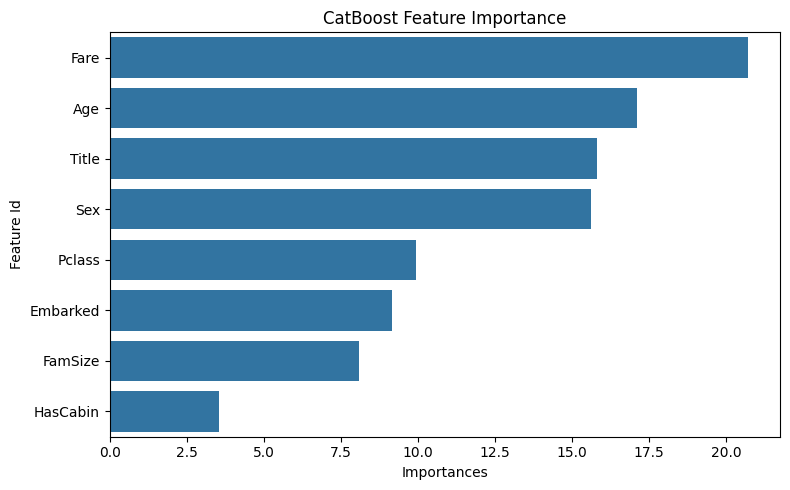

In [248]:
plt.figure(figsize=(8, 5))
sns.barplot(data=fi, x='Importances', y='Feature Id', orient='h')
plt.title('CatBoost Feature Importance')
plt.tight_layout()
plt.show()

SUBMISSION

In [ ]:
test_preds = model_cb.predict(test_df[X_cb.columns])

submission = test_df.reset_index()[['PassengerId']].copy()
submission['Survived'] = test_preds.astype(int)

submission.to_csv('submission.csv', index=False)
print(submission.head())
print(submission.shape)